In [1]:
#data visualization 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from matplotlib import pyplot
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_pacf
from gdeep.utility.extended_persistence import graph_extended_persistence_hks 

#graph theory 
import networkx as nx
import numpy as np

#tda
from gtda.homology import VietorisRipsPersistence,FlagserPersistence,EuclideanCechPersistence
from gtda.diagrams import PersistenceEntropy

#tqdm
from tqdm import tqdm

#for copy
import copy

#pd np
import pandas as pd 
import numpy as np 

#stat
import scipy.stats

/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


No TPUs...


## Reading Data

In [2]:
raw_data = pd.read_csv('tij_SFHH.dat_.csv')
node_list = [] 
node_list.extend(list(raw_data['i'].unique()))
node_list.extend(list(raw_data['j'].unique()))
node_list = list(set(node_list))
n_nodes = len(node_list)

G_conf = nx.Graph()

for row_index in tqdm(range(len(raw_data))):
    v1 = raw_data.iloc[row_index]['i']
    v2 = raw_data.iloc[row_index]['j']
    
    if not G_conf.has_edge(v1,v2):
        G_conf.add_weighted_edges_from([(v1,v2,1)])
    else:
        weight = G_conf.get_edge_data(v1,v2)['weight']   
        G_conf.add_weighted_edges_from([(v1,v2,weight+1)])

100%|██████████| 70261/70261 [00:10<00:00, 6451.17it/s]


## Infection step: 
 **Here, we implemented a step of infection, which means that each node $i$ with at least $th_i$ infected neighbours will be infected here.** 


In [3]:
def do_transfers(Graph,list_inf,weight_normalizer,simple, th=2, betha = 0.5, q_complex=0.1):
    #if this infection is simple
    if simple:
        new_infected_marker = False
        new_infected_nodes = [] 
        
        all_nodes = list(Graph.nodes)
        
        for i in all_nodes:
            if i in list_inf:
                continue
        
            else:
                pr_infection = 0 
                pi_calc = 1
                edges = list(Graph.neighbors(i))
                for j in edges:
                    if j in list_inf:
                        pi_calc *= (1-betha*(Graph.get_edge_data(i,j)['weight']/weight_normalizer))
                        pr_infection = 1 - pi_calc
                threshold_prob_simple = np.random.uniform(0,1)
                
                if threshold_prob_simple <= pr_infection:
                    new_infected_marker = True
                    new_infected_nodes.append(i)
        
        for i in new_infected_nodes:
            list_inf.append(i)
    
        return new_infected_marker, list_inf
    
    #complex 
    else:
        new_infected_marker = False
        new_infected_nodes = [] 
        
        all_nodes = list(Graph.nodes)
        for i in all_nodes:
        
            if i in list_inf:
                continue
                
            else:
                summation_infected = 0
                summation_whole = 0
                edges = list(Graph.neighbors(i))
                for j in edges:
                    summation_whole += (Graph.get_edge_data(i,j)['weight']/weight_normalizer)
                    if j in list_inf:
                        summation_infected += (Graph.get_edge_data(i,j)['weight']/weight_normalizer)
                if summation_whole == 0:
                    print(i)
                if summation_infected/summation_whole >= th:
                    new_infected_marker = True
                    new_infected_nodes.append(i)
        
        for i in new_infected_nodes:
            list_inf.append(i)
        
        return new_infected_marker, list_inf

# Main Boday

## Complex

In [4]:
def doing_comlpex_contagion():
    #Complex Contagion

    #do we have new infection? 
    new_infected_nodes = True

    #counter of infection steps
    tim_curr = 0

    #graph and init infected nodes 
    G = copy.deepcopy(G_fixed)
    list_inf = copy.deepcopy(list_inf_copy)

    #Adj matrix 
    A = nx.to_numpy_array(G)
    weight_normalizer = np.max(A)
    
    #list of nodes 
    all_nodes_list = list(G.nodes)
    
    #when every nodes got infected (None if hasn’t infected yet)
    step_of_infection_per_node = [None for i in range(n)]


    #iterations of infection
    while new_infected_nodes:
        tim_curr += 1
        new_infected_nodes, list_inf = do_transfers(G,list_inf,weight_normalizer,simple=False, th=0.01,q_complex=0.1)

        for nod_indx in list_inf:
            if step_of_infection_per_node[all_nodes_list.index(nod_indx)] == None:
                step_of_infection_per_node[all_nodes_list.index(nod_indx)] = tim_curr


    #classic approach 
    degrees_list = list(dict(G.degree).values())
    infection_order = np.array(step_of_infection_per_node,dtype=float)
    try:
        rho, p_value = scipy.stats.spearmanr(degrees_list, infection_order,nan_policy='omit')
    except:
        rho = 0
    complex_deg_order.append(rho)

    # adding all edges between infected vertices 
    for i in all_nodes_list:
        for j in all_nodes_list:
            if i != j:
                if i in list_inf and j in list_inf:
                    G.add_edge(i,j)  
    #extended persistent homology
    A = nx.to_numpy_array(G)
    ext_ph = graph_extended_persistence_hks(A)
    ext_ph = ext_ph.get_raw_data()
    ext_ph = ext_ph.numpy()
    dim1 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][3] == 1 else 0 for i in range(len(ext_ph))])
    dim0 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][2] == 1 else 0 for i in range(len(ext_ph))])
    dim2 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][4] == 1 else 0 for i in range(len(ext_ph))])
    dim3 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][5] == 1 else 0 for i in range(len(ext_ph))])

    complex_list_EPH1.append(dim1)
    complex_list_EPH0.append(dim0)
    complex_list_EPH2.append(dim2)
    complex_list_EPH3.append(dim3)

## Simple

In [5]:
def doing_simple_contagion():
    #simple Contagion

    #do we have new infection? 
    new_infected_nodes = True

    #counter of infection steps
    tim_curr = 0

    #graph and init infected nodes 
    G = copy.deepcopy(G_fixed)
    list_inf = copy.deepcopy(list_inf_copy)

    #Adj matrix 
    A = nx.to_numpy_array(G)
    weight_normalizer = np.max(A)
    
    #list of nodes 
    all_nodes_list = list(G.nodes)

    #when every nodes got infected (None if hasn’t infected yet)
    step_of_infection_per_node = [None for i in range(n)]

    #iterations of infection
    while new_infected_nodes:
        tim_curr += 1
        new_infected_nodes, list_inf = do_transfers(G,list_inf,weight_normalizer,simple=True, betha=0.005)
        
        for nod_indx in list_inf:
            if step_of_infection_per_node[all_nodes_list.index(nod_indx)] == None:
                step_of_infection_per_node[all_nodes_list.index(nod_indx)] = tim_curr 
                
    #classic approach 
    degrees_list = list(dict(G.degree).values())
    infection_order = np.array(step_of_infection_per_node,dtype=float)
    try:
        rho, p_value = scipy.stats.spearmanr(degrees_list, infection_order,nan_policy='omit')
    except:
        rho = 0
    simple_deg_order.append(rho)

    # adding all edges between infected vertices 
    for i in all_nodes_list:
        for j in all_nodes_list:
            if i != j:
                if i in list_inf and j in list_inf:
                    G.add_edge(i,j)  
                    
    #extended persistent homology
    A = nx.to_numpy_array(G)
    ext_ph = graph_extended_persistence_hks(A)
    ext_ph = ext_ph.get_raw_data()
    ext_ph = ext_ph.numpy()
    dim1 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][3] == 1 else 0 for i in range(len(ext_ph))])
    dim0 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][2] == 1 else 0 for i in range(len(ext_ph))])
    dim2 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][4] == 1 else 0 for i in range(len(ext_ph))])
    dim3 = np.sum([ext_ph[i][1]-ext_ph[i][0] if ext_ph[i][5] == 1 else 0 for i in range(len(ext_ph))])

    simple_list_EPH1.append(dim1)
    simple_list_EPH0.append(dim0)
    simple_list_EPH2.append(dim2)

    simple_list_EPH3.append(dim3)

In [7]:
#list for different statistics 
complex_list_VR1 = []
simple_list_VR1 = [] 

complex_list_ninf = [] 
simple_list_ninf = [] 

complex_list_EPH1 = []
simple_list_EPH1 = [] 

complex_list_EPH0 = []
simple_list_EPH0 = [] 

complex_list_EPH2 = []
simple_list_EPH2 = [] 


complex_list_EPH3 = []
simple_list_EPH3 = [] 

simple_n_cliques3 = [] 
complex_n_cliques3 = [] 

simple_n_cliques4 = [] 
complex_n_cliques4 = [] 


simple_deg_order = [] 
complex_deg_order = [] 


for iteration_indx in tqdm(range(700)):
    
    #initilize graph and infected nodes 
    n = n_nodes
    n_subgraph = n_nodes
    G_fixed = G_conf

    #init infected nodes 
    initial_infected_node = np.random.randint(n_nodes)
    list_inf = [list(G_conf.nodes)[initial_infected_node]]


    #creating a copy of initial graph and its infected nodes 
    G_copy = copy.deepcopy(G_fixed)
    list_inf_copy = copy.deepcopy(list_inf)
    
    #simple and complex contagion
    doing_comlpex_contagion()
    doing_simple_contagion()

 32%|███▏      | 223/700 [2:42:03<1:08:20,  8.60s/it]    /usr/local/lib/python3.8/site-packages/scipy/stats/mstats_basic.py:507: RuntimeWarning:

invalid value encountered in true_divide

100%|██████████| 700/700 [4:17:36<00:00, 22.08s/it]    


## Visualization 

3. EXPH dim 0

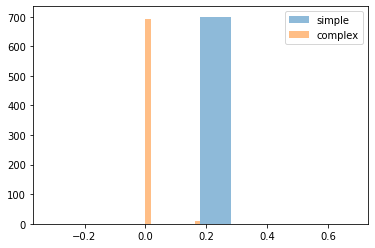

In [8]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_EPH0,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH0,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

4. EXPH dim 1

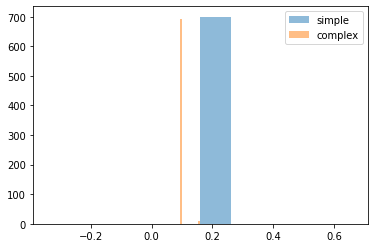

In [9]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_EPH1,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH1,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()

4. EXPH dim 2

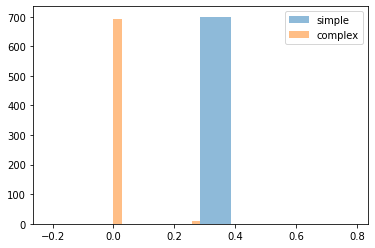

In [10]:
import random
import numpy
from matplotlib import pyplot


pyplot.hist(simple_list_EPH2,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH2,  alpha=0.5, label='complex')

pyplot.legend(loc='upper right')
pyplot.show()


5. EXPH dim 3

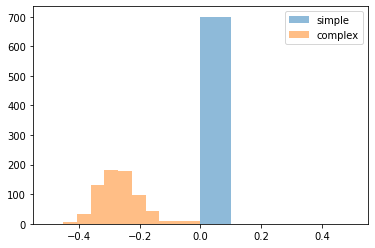

In [11]:
import random
import numpy
from matplotlib import pyplot



pyplot.hist(simple_deg_order,  alpha=0.5, label='simple')
pyplot.hist(complex_deg_order,  alpha=0.5, label='complex')
# pyplot.hist(14*(((np.array(simple_list_EPH3)/210)-16)/2.97),  alpha=0.5, label='simple_normalized')

pyplot.legend(loc='upper right')
pyplot.show()

6. Classic approach

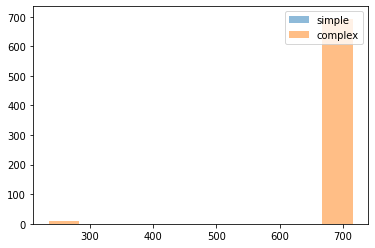

In [12]:
import random
import numpy
from matplotlib import pyplot



pyplot.hist(simple_list_EPH3,  alpha=0.5, label='simple')
pyplot.hist(complex_list_EPH3,  alpha=0.5, label='complex')
# pyplot.hist(14*(((np.array(simple_list_EPH3)/210)-16)/2.97),  alpha=0.5, label='simple_normalized')

pyplot.legend(loc='upper right')
pyplot.show()

## t-tests

In [13]:
from scipy import stats
print(stats.ttest_ind(simple_list_VR1, complex_list_VR1))
print(stats.ttest_ind(simple_list_ninf, complex_list_ninf))

Ttest_indResult(statistic=nan, pvalue=nan)
Ttest_indResult(statistic=nan, pvalue=nan)


In [14]:
print(stats.ttest_ind(simple_list_EPH0, complex_list_EPH0))
print(stats.ttest_ind(simple_list_EPH1, complex_list_EPH1))
print(stats.ttest_ind(simple_list_EPH2, complex_list_EPH2))
print(stats.ttest_ind(simple_list_EPH3, complex_list_EPH3))

Ttest_indResult(statistic=245.8932695296884, pvalue=0.0)
Ttest_indResult(statistic=245.89326952968844, pvalue=0.0)
Ttest_indResult(statistic=245.89326952968844, pvalue=0.0)
Ttest_indResult(statistic=-245.89326952968844, pvalue=0.0)


In [15]:
print(stats.ttest_ind(np.nan_to_num(simple_deg_order),np.nan_to_num(complex_deg_order)))

Ttest_indResult(statistic=97.75476702929497, pvalue=0.0)


# Using ML methods 

### creating data sets 

In [16]:
len(complex_deg_order),len(simple_deg_order)

(700, 700)

In [17]:
simples_df = pd.DataFrame()
simples_df['PH1'] = simple_list_VR1
simples_df['EXP0'] = simple_list_EPH0
simples_df['EXP1'] = simple_list_EPH1
simples_df['EXP2'] = simple_list_EPH2
simples_df['deg'] = simple_deg_order

simples_df['label'] = [0 for i in range(len(simples_df))]

In [18]:
complex_df = pd.DataFrame()
complex_df['PH1'] = complex_list_VR1
complex_df['EXP0'] = complex_list_EPH0
complex_df['EXP1'] = complex_list_EPH1
complex_df['EXP2'] = complex_list_EPH2
complex_df['deg'] = complex_deg_order

complex_df['label'] = [1 for i in range(len(complex_df))]

In [19]:
all_df = pd.concat([simples_df,complex_df])
all_df = all_df.sample(len(all_df))
all_df.fillna(0,inplace=True)

In [20]:
all_df.corr()

,PH1,EXP0,EXP1,EXP2,deg,label
PH1,NaN,NaN,NaN,NaN,NaN,NaN
EXP0,NaN,1.000000,1.000000,1.000000,0.944746,-0.988636
EXP1,NaN,1.000000,1.000000,1.000000,0.944746,-0.988636
EXP2,NaN,1.000000,1.000000,1.000000,0.944746,-0.988636
deg,NaN,0.944746,0.944746,0.944746,1.000000,-0.934010
label,NaN,-0.988636,-0.988636,-0.988636,-0.934010,1.000000


### Our model 

In [38]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

X = all_df[['EXP2']]
y = all_df['label']

X_train, y_train = X[:10], y[:10]
X_test, y_test = X[10:],y[10:] 

In [39]:
clf.fit(X_train,y_train)
y_hat = clf.predict(X_test)

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       697
           1       1.00      0.99      0.99       693

    accuracy                           0.99      1390
   macro avg       0.99      0.99      0.99      1390
weighted avg       0.99      0.99      0.99      1390



## Baseline

In [41]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

X = all_df[['deg']]
y = all_df['label']

X_train, y_train = X[:10], y[:10]
X_test, y_test = X[10:],y[10:] 

In [42]:
clf.fit(X_train,y_train)
y_hat = clf.predict(X_test)

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       697
           1       1.00      0.98      0.99       693

    accuracy                           0.99      1390
   macro avg       0.99      0.99      0.99      1390
weighted avg       0.99      0.99      0.99      1390

